In [3]:
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split

In [4]:
ruta_dataset = Path("../data/raw")
clases = sorted([carpeta.name for carpeta in ruta_dataset.iterdir() if carpeta.is_dir()])

print("Clases encontradas:")
print(clases)

Clases encontradas:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## Construcción de la tabla base del dataset
En esta sección se genera una tabla con la ruta de cada imagen y su etiqueta de clase, para facilitar la partición y el modelado posterior.

In [6]:
registros_dataset = []

# Recorremos cada carpeta de clase
for clase in clases:
    carpeta_clase = ruta_dataset / clase
    imagenes = list(carpeta_clase.glob("*.jpg"))
    
    for img_path in imagenes:
        registros_dataset.append({
            "ruta": str(img_path),
            "clase": clase
        })

# Convertimos a DataFrame
df_dataset = pd.DataFrame(registros_dataset)

# Mostramos las primeras filas
df_dataset.head()

,ruta,clase
0,..\data\raw\angry\angry_00000.jpg,angry
1,..\data\raw\angry\angry_00001.jpg,angry
2,..\data\raw\angry\angry_00002.jpg,angry
3,..\data\raw\angry\angry_00003.jpg,angry
4,..\data\raw\angry\angry_00004.jpg,angry


## Revisión de la tabla generada
Se verifica la cantidad total de imágenes y la distribución de clases antes de realizar la partición.

In [7]:
print("Total de imágenes:", len(df_dataset))
df_dataset["clase"].value_counts()

Total de imágenes: 49779


clase
happy       11398
neutral      8166
sad          6535
angry        5920
disgust      5920
fear         5920
surprise     5920
Name: count, dtype: int64

## Partición del dataset
Se divide el conjunto de datos en entrenamiento, validación y prueba de manera estratificada, para conservar la proporción de clases en cada subconjunto.

In [8]:
# Primera división: entrenamiento y conjunto temporal
df_train, df_temp = train_test_split(
    df_dataset,
    test_size=0.30,
    stratify=df_dataset["clase"],
    random_state=42
)

# Segunda división: validación y prueba
df_val, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    stratify=df_temp["clase"],
    random_state=42
)

print("Train:", len(df_train))
print("Validation:", len(df_val))
print("Test:", len(df_test))

Train: 34845
Validation: 7467
Test: 7467


## Verificación de la distribución por clase
Aquí se comprueba que la proporción de clases se conserve de manera similar en entrenamiento, validación y prueba.

In [9]:
print("Distribución en train:")
print(df_train["clase"].value_counts(normalize=True).sort_index())

print("\nDistribución en validation:")
print(df_val["clase"].value_counts(normalize=True).sort_index())

print("\nDistribución en test:")
print(df_test["clase"].value_counts(normalize=True).sort_index())

Distribución en train:
clase
angry       0.118927
disgust     0.118927
fear        0.118927
happy       0.228986
neutral     0.164041
sad         0.131267
surprise    0.118927
Name: proportion, dtype: float64

Distribución en validation:
clase
angry       0.118923
disgust     0.118923
fear        0.118923
happy       0.228874
neutral     0.164055
sad         0.131378
surprise    0.118923
Name: proportion, dtype: float64

Distribución en test:
clase
angry       0.118923
disgust     0.118923
fear        0.118923
happy       0.229008
neutral     0.164055
sad         0.131244
surprise    0.118923
Name: proportion, dtype: float64


## Codificación de clases
En esta parte se asigna un índice numérico a cada emoción para facilitar el entrenamiento del modelo.

In [10]:
clases_ordenadas = sorted(df_dataset["clase"].unique())

clase_a_indice = {clase: idx for idx, clase in enumerate(clases_ordenadas)}
indice_a_clase = {idx: clase for clase, idx in clase_a_indice.items()}

print("Clase a índice:")
print(clase_a_indice)

Clase a índice:
{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [11]:
df_train = df_train.copy()
df_val = df_val.copy()
df_test = df_test.copy()

df_train["label"] = df_train["clase"].map(clase_a_indice)
df_val["label"] = df_val["clase"].map(clase_a_indice)
df_test["label"] = df_test["clase"].map(clase_a_indice)

df_train.head()

,ruta,clase,label
2743,..\data\raw\angry\angry_02743.jpg,angry,0
17350,..\data\raw\fear\fear_aug01535.jpg,fear,2
8083,..\data\raw\disgust\disgust_aug01008.jpg,disgust,1
46650,..\data\raw\surprise\surprise_02791.jpg,surprise,6
23764,..\data\raw\happy\happy_07420.jpg,happy,3


## Resumen final de la preparación
Se resume el número de clases y el tamaño de cada subconjunto generado.

In [12]:
print("Número de clases:", len(clases_ordenadas))
print("Clases:", clases_ordenadas)

print("\nTamaño de los subconjuntos:")
print("Train:", df_train.shape)
print("Validation:", df_val.shape)
print("Test:", df_test.shape)

Número de clases: 7
Clases: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Tamaño de los subconjuntos:
Train: (34845, 3)
Validation: (7467, 3)
Test: (7467, 3)


## Recapitulación
En esta etapa se preparó el dataset para el modelado mediante la construcción de una tabla base con la ruta de cada imagen y su clase correspondiente. A partir de esta estructura, se realizó una partición estratificada en entrenamiento, validación y prueba, lo que permitió conservar de manera equilibrada la proporción de cada emoción en los tres subconjuntos. Además, se asignó una codificación numérica a las clases para facilitar el entrenamiento posterior del modelo. En general, esta fase permitió dejar el conjunto de datos organizado y listo para pasar a la carga de imágenes, aplicación de transformaciones y construcción del modelo de clasificación.

## Transformaciones de imágenes
En esta sección se definen las transformaciones que se aplicarán a las imágenes para prepararlas para el entrenamiento del modelo.  
Se utilizará aumento de datos en entrenamiento y un preprocesamiento básico en validación y prueba.

In [17]:
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import torch

In [18]:
transform_train = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

transform_val_test = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
])

## Dataset personalizado
Se define una clase personalizada para cargar las imágenes a partir de las rutas almacenadas en los subconjuntos del dataset.

In [19]:
from PIL import Image

In [20]:
class EmotionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, "ruta"]
        label = self.dataframe.loc[idx, "label"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

## Creación de datasets
Aquí se construyen los datasets de entrenamiento, validación y prueba utilizando la clase personalizada definida previamente.

In [21]:
train_dataset = EmotionDataset(df_train, transform=transform_train)
val_dataset = EmotionDataset(df_val, transform=transform_val_test)
test_dataset = EmotionDataset(df_test, transform=transform_val_test)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 34845
Validation dataset: 7467
Test dataset: 7467


## Creación de DataLoaders
En esta sección se crean los DataLoaders para cargar las imágenes por lotes durante el entrenamiento, validación y prueba.

In [22]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("DataLoaders creados correctamente")

DataLoaders creados correctamente


## Visualización de un lote de entrenamiento
Aquí se muestran algunas imágenes del conjunto de entrenamiento para verificar que la carga, las transformaciones y las etiquetas se estén aplicando correctamente.

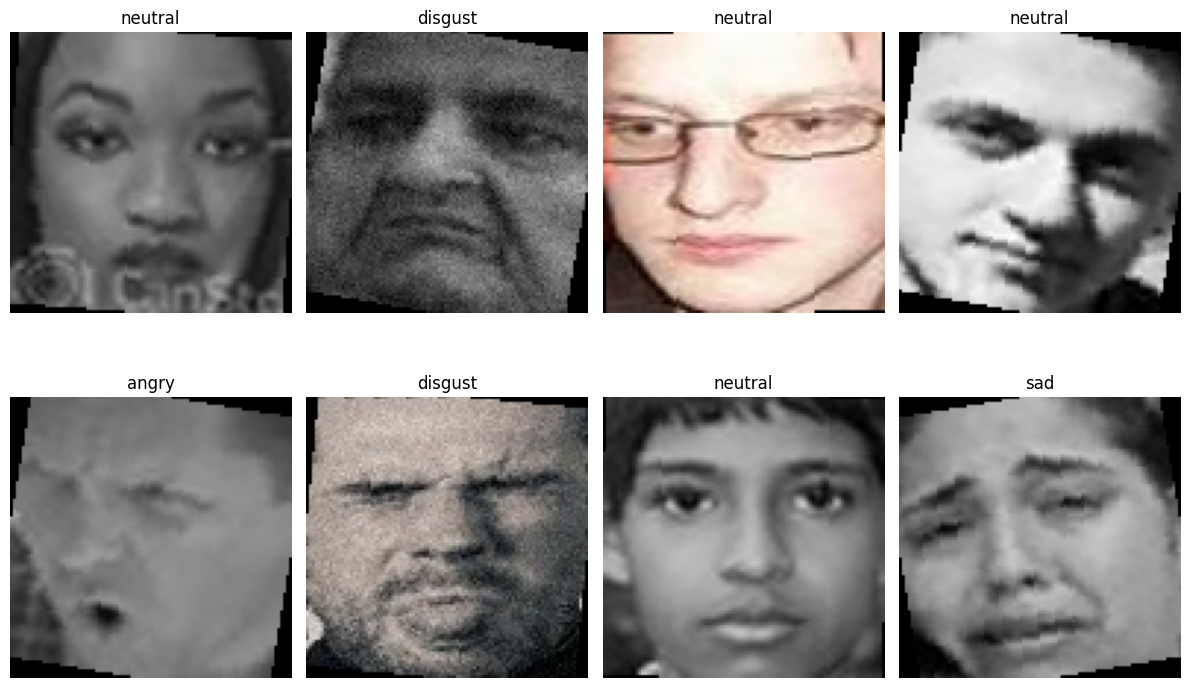

In [26]:
import matplotlib.pyplot as plt
imagenes, etiquetas = next(iter(train_loader))

plt.figure(figsize=(12, 8))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    img = imagenes[i].permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(indice_a_clase[etiquetas[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Conclusión 
En la primera parte del notebook se organizó el dataset a nivel estructural, construyendo la tabla base, realizando la partición estratificada y codificando las clases. En la última parte, esa información se transformó en una estructura utilizable para aprendizaje profundo, mediante transformaciones de imágenes, un dataset personalizado y la creación de DataLoaders. Es decir, primero se dejó el dataset ordenado y después se preparó para que una red neuronal pudiera procesarlo por lotes.